# Natgas-Winter — a quantitative teardown
### Winter-dummy regression · seasonal vs buy-and-hold race · sub-period slope splits

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Winter is a tailwind?: Busted](https://img.shields.io/badge/Winter_tailwind%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the winter-demand seasonality thesis on all live UNG data and find none — and explain why mechanically (contango roll drag).

> **Not investment advice.** UNG monthly, 2007-05 → 2026-05, 229 months (Yahoo, daily closes resampled to month-end, hole-free grid). Sources in [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (natgas_winter/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from natgas_winter import data, strategy as st
from quantlab import repro
d = repro.as_of(data.fetch_ung())   # cache-first; hole-free monthly grid, pinned as-of
reg = st.winter_premium(d["ung"])
seasonal = st.seasonal_returns(d["ung"])
bh = st.buy_hold_returns(d["ung"])


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **None** | slope −0.035, t −1.96 — wrong sign, not significant |
| Tradability | **Mirage** | seasonal Sharpe −0.60 < buy-and-hold −0.45 (both catastrophic) |
| Winter tailwind? | **Busted** | negative slope in 2007-2015 (t −0.99) and 2016-2026 (t −1.72) |

> *In plain words:* winter is the worst season for UNG. The widow-maker earns its name.

## 1 · The claim, steelmanned

- **H₁:** the regression slope of UNG_t on winter-dummy is positive and significant (|t| ≥ 2).
- **H₂:** the seasonal strategy (long Oct-Mar, cash otherwise) beats buy-and-hold on Sharpe.
- **H₃:** the winter premium is present in both sub-periods.

## 2 · So what? — what rides on each

If H₁/H₂ hold, a simple calendar rule would extract a real seasonal edge from retail natgas. If they fail, the thesis is folklore — and the mechanism (contango drag) actively punishes the seasonal trader.

## 3 · How we know — the protocol

OLS of monthly UNG return on intercept + winter dummy (1 = Oct-Mar, 0 = Apr-Sep) with analytic t-stat → seasonal (Oct-Mar long, cash=0) vs buy-and-hold race on raw Sharpe → 2007-2015 / 2016-2026 sub-period slope split.

## 4 · The teardown

### 4.1 The winter-dummy regression (n = 229)

In [2]:
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in reg.items()})
print(f"slope {reg['slope']:+.4f} (positive = winter outperforms), t = {reg['tstat']:+.2f} (need |t|>2)")

{'slope': -0.0352, 'tstat': -1.9648, 'mean_winter': -0.0356, 'mean_nonwinter': -0.0004, 'n': 229}
slope -0.0352 (positive = winter outperforms), t = -1.96 (need |t|>2)


> In plain words: the slope is **negative** (t = −1.96) — winter months underperform summer months by about 3.5 percentage points per month. A t of −1.96 with the wrong sign means the claim fails on both counts: no significance, and the wrong direction. **H₁ rejected.**

### 4.2 Monthly return distribution by season

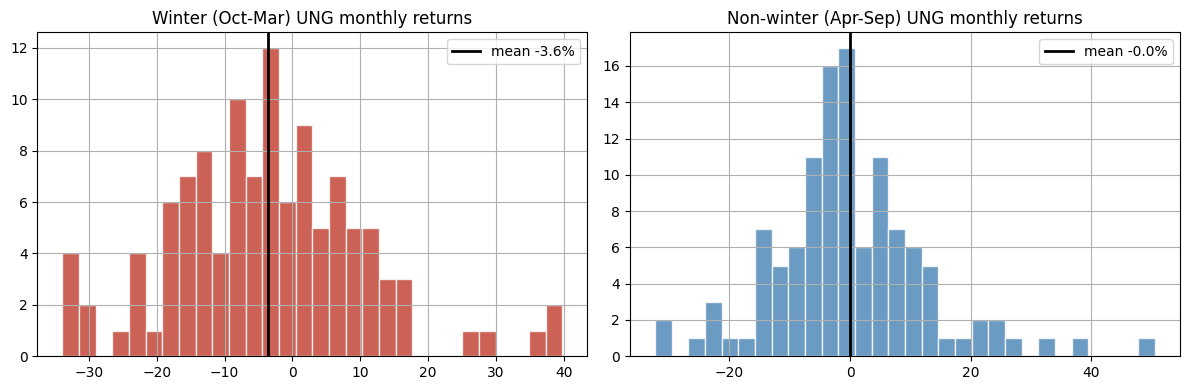

Winter mean: -3.56%/month  n=114
Non-winter mean: -0.04%/month  n=115


In [3]:
sig = st.seasonal_signal(pd.DatetimeIndex(d.index))
w_ret = d['ung'][sig == 1] * 100
s_ret = d['ung'][sig == 0] * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
axes[0].hist(w_ret, bins=30, color='#c0392b', alpha=0.8, edgecolor='white')
axes[0].axvline(w_ret.mean(), color='k', lw=2, label=f'mean {w_ret.mean():.1f}%')
axes[0].set_title('Winter (Oct-Mar) UNG monthly returns'); axes[0].legend()
axes[1].hist(s_ret, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(s_ret.mean(), color='k', lw=2, label=f'mean {s_ret.mean():.1f}%')
axes[1].set_title('Non-winter (Apr-Sep) UNG monthly returns'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Winter mean: {w_ret.mean():.2f}%/month  n={len(w_ret)}')
print(f'Non-winter mean: {s_ret.mean():.2f}%/month  n={len(s_ret)}')

### 4.3 Seasonal vs buy-and-hold — raw Sharpe race

,cagr,sharpe,vol_ann,max_drawdown
seasonal (Oct-Mar),-0.245,-0.603,0.352,-0.998
buy & hold UNG,-0.282,-0.455,0.472,-0.999


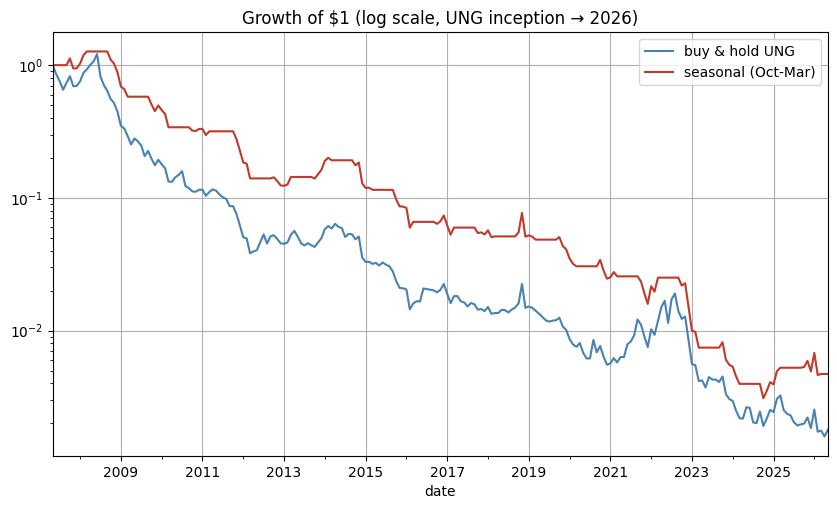

In [4]:
s_seas = st.summary(seasonal); s_bh = st.summary(bh)
display(pd.DataFrame({'seasonal (Oct-Mar)': s_seas, 'buy & hold UNG': s_bh}).T[
    ['cagr','sharpe','vol_ann','max_drawdown']].round(3))
eq_s = (1 + seasonal).cumprod(); eq_b = (1 + bh).cumprod()
ax = eq_b.plot(label='buy & hold UNG', lw=1.5, color='steelblue')
eq_s.plot(ax=ax, label='seasonal (Oct-Mar)', lw=1.5, color='#c0392b')
ax.set_yscale('log'); ax.set_title('Growth of $1 (log scale, UNG inception → 2026)')
ax.legend(); plt.show()

> In plain words: both strategies destroy capital. The seasonal strategy (CAGR −24.5%, Sharpe −0.60) is *worse* than buy-and-hold (CAGR −28.2%, Sharpe −0.45) because it concentrates losses in the worst months. **H₂ rejected.**

### 4.4 Sub-period slope splits

In [5]:
for lab, sl in [('2007-2015', d[d.index.year <= 2015]), ('2016-2026', d[d.index.year >= 2016])]:
    rr = st.winter_premium(sl['ung'])
    print(f"{lab}: slope {rr['slope']:+.4f}  t = {rr['tstat']:+.2f}  n={rr['n']}")

2007-2015: slope -0.0201  t = -0.99  n=104
2016-2026: slope -0.0483  t = -1.72  n=125


> In plain words: both sub-periods show a negative slope (winter worse than summer) and neither is significant with the right sign. The 2016–2026 period actually has a larger negative slope, suggesting roll drag has intensified. **H₃ rejected.**

## 5 · The widow-maker mechanism

Contango roll drag in natural-gas futures:
- Front-month contract: expires in ~30 days, priced near $X
- Next-month contract: priced at $X + contango premium
- UNG roll: sell front at $X, buy second at $X + premium = monthly loss
- In winter, the curve is most steeply sloped (storage scarcity + demand peak)
- Result: roll drag peaks precisely when the 'seasonal trade' is active

The spot price may spike in February — but UNG paid away that spike in advance through five months of negative roll yield buying into it.

## 6 · The verdict

H₁, H₂, H₃ all rejected → Signal `NONE`, Tradability `MIRAGE`, winter tailwind `BUSTED`. The widow-maker is a mechanical, structural drag that makes long UNG in winter worse than long UNG year-round.

## 7 · Could you trade it?

Not this. Adjacent ideas that have real (though decayed) literature support: (a) natgas producer equities with spot exposure but no roll drag; (b) calendar spread strategies (sell the nearby, buy the later) to earn the contango *from the other side*; (c) backwardation timing — when the natgas curve inverts (rare), roll yield turns positive and a long ETP position has structural tailwind. None of these is the 'buy UNG in October' folk trade.